In [23]:
import yfinance as yf

ticker_symbol = '^IXIC'
start_date = '2016-01-01'

nasdaq_data = yf.download(ticker_symbol, start=start_date)

print("NASDAQ Composite Index data downloaded successfully.")
print(nasdaq_data.head())

print('Missing values per column:')
display(nasdaq_data.isnull().sum())

print('\nTotal rows:', nasdaq_data.shape[0])
print('Total columns:', nasdaq_data.shape[1])

/tmp/ipython-input-323/583897538.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nasdaq_data = yf.download(ticker_symbol, start=start_date)
[*********************100%***********************]  1 of 1 completed

NASDAQ Composite Index data downloaded successfully.
Price             Close         High          Low         Open      Volume
Ticker            ^IXIC        ^IXIC        ^IXIC        ^IXIC       ^IXIC
Date                                                                      
2016-01-04  4903.089844  4903.089844  4846.979980  4897.649902  2218420000
2016-01-05  4891.430176  4926.729980  4872.740234  4917.839844  1927380000
2016-01-06  4835.759766  4866.040039  4804.689941  4813.759766  2168620000
2016-01-07  4689.430176  4788.020020  4688.169922  4736.399902  2552590000
2016-01-08  4643.629883  4742.569824  4637.850098  4722.020020  2288750000
Missing values per column:


,,0
Price,Ticker,
Close,^IXIC,0
High,^IXIC,0
Low,^IXIC,0
Open,^IXIC,0
Volume,^IXIC,0



Total rows: 2551
Total columns: 5


In [24]:
import pandas as pd

nasdaq_data_reset = nasdaq_data.reset_index()

# Create a new dataframe for Prophet
df_prophet = pd.DataFrame()
df_prophet['ds'] = nasdaq_data_reset['Date']
df_prophet['y'] = nasdaq_data_reset['Close']['^IXIC']

# Filter for training data from 2016-01-01 to 2021-12-31
start_train = '2016-01-01'
end_train = '2022-01-01'

train_data = df_prophet[(df_prophet['ds'] >= start_train) & (df_prophet['ds'] < end_train)]

print(f"Training Data Range: {train_data['ds'].min()} to {train_data['ds'].max()}")
print(f"Number of training samples: {len(train_data)}")

Training Data Range: 2016-01-04 00:00:00 to 2021-12-31 00:00:00
Number of training samples: 1511


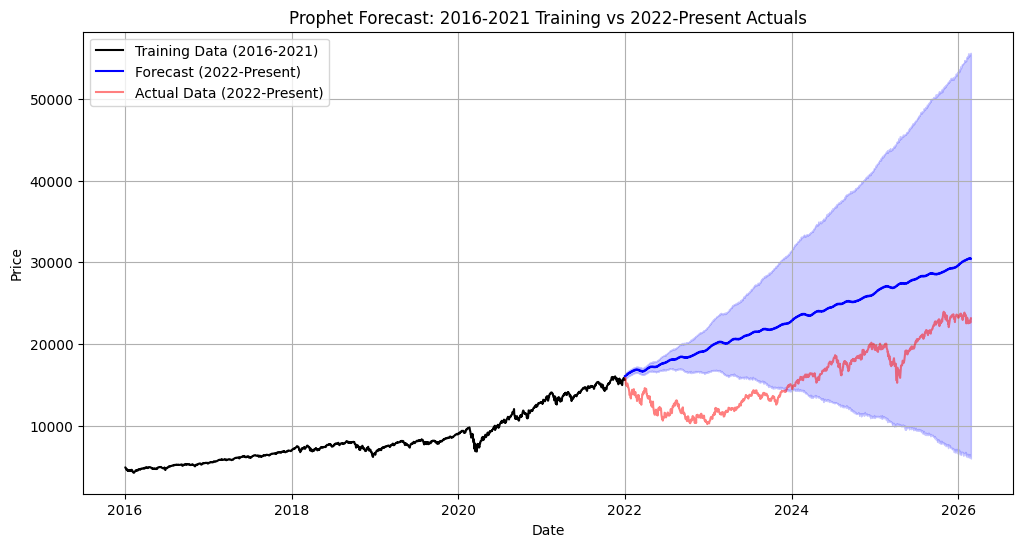

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# Plot Training Data
plt.plot(train_data['ds'], train_data['y'], label='Training Data (2016-2021)', color='black')

# Plot Forecast
forecast_future = forecast[forecast['ds'] >= '2022-01-01']
plt.plot(forecast_future['ds'], forecast_future['yhat'], label='Forecast (2022-Present)', color='blue')
plt.fill_between(forecast_future['ds'], forecast_future['yhat_lower'], forecast_future['yhat_upper'], color='blue', alpha=0.2)

# Plot Actual Data for the forecast period
actual_future = df_prophet[df_prophet['ds'] >= '2022-01-01']
if not actual_future.empty:
    plt.plot(actual_future['ds'], actual_future['y'], label='Actual Data (2022-Present)', color='red', alpha=0.5)

plt.title('Prophet Forecast: 2016-2021 Training vs 2022-Present Actuals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
from prophet.diagnostics import cross_validation, performance_metrics

# Define cross-validation parameters
initial = '600 days'
period = '5 days'
horizon = '5 days'

print(f"Cross-Validation Parameters:\nInitial Training Period: {initial}\nPeriod (Cutoff Spacing): {period}\nForecast Horizon: {horizon}")

Cross-Validation Parameters:
Initial Training Period: 600 days
Period (Cutoff Spacing): 5 days
Forecast Horizon: 5 days


In [27]:
import logging
from prophet import Prophet
from prophet.diagnostics import cross_validation

# Suppress Prophet's informative logs to keep the output clean during cross-validation
logging.getLogger('prophet').setLevel(logging.ERROR)


print("Fitting model on the entire dataset (2016-Present)...")
model_full = Prophet(daily_seasonality=True)
model_full.fit(df_prophet)

# Perform cross-validation
print("Starting cross-validation on full dataset...")
df_cv = cross_validation(model_full, initial=initial, period=period, horizon=horizon)

print("Cross-validation completed.")
print(f"Results range: {df_cv['ds'].min()} to {df_cv['ds'].max()}")
print(df_cv.tail())

Fitting model on the entire dataset (2016-Present)...
Starting cross-validation on full dataset...


  0%|          | 0/621 [00:00<?, ?it/s]

Cross-validation completed.
Results range: 2017-08-28 00:00:00 to 2026-02-25 00:00:00
             ds          yhat    yhat_lower    yhat_upper             y  \
2130 2026-02-19  23385.452272  22667.271596  24131.281249  22682.730469   
2131 2026-02-20  23379.160846  22658.496920  24115.145438  22886.070312   
2132 2026-02-23  23304.065421  22592.422221  24057.943543  22627.269531   
2133 2026-02-24  23284.690765  22506.863491  23982.446470  22863.679688   
2134 2026-02-25  23267.548766  22534.316574  23990.399494  23152.080078   

         cutoff  
2130 2026-02-15  
2131 2026-02-15  
2132 2026-02-20  
2133 2026-02-20  
2134 2026-02-20  


**Reasoning**:
Calculate performance metrics (MAE, RMSE, MAPE) using the results from the cross-validation.



In [28]:
from prophet.diagnostics import performance_metrics

# Calculate performance metrics on the updated df_cv
df_p = performance_metrics(df_cv)

# Display the metrics
print("Performance Metrics (Head):")
print(df_p.head())

# Calculate and print average MAE, RMSE, and MAPE
avg_mae = df_p['mae'].mean()
avg_rmse = df_p['rmse'].mean()
avg_mape = df_p['mape'].mean()

print(f"\nUpdated Backtest Metrics (2017-2026):")
print(f"Average MAE: {avg_mae:.2f}")
print(f"Average RMSE: {avg_rmse:.2f}")
print(f"Average MAPE: {avg_mape:.2%}")

Performance Metrics (Head):
  horizon           mse         rmse         mae      mape     mdape  \
0  1 days  1.089512e+06  1043.797115  724.116846  0.055619  0.034281   
1  2 days  1.084174e+06  1041.236861  715.941623  0.055050  0.033394   
2  3 days  1.077875e+06  1038.207431  723.064288  0.055383  0.035309   
3  4 days  1.126209e+06  1061.229785  740.102105  0.057507  0.037198   
4  5 days  1.157386e+06  1075.818808  756.348707  0.059238  0.037389   

      smape  coverage  
0  0.055814  0.382284  
1  0.055173  0.404206  
2  0.055571  0.377672  
3  0.057744  0.370892  
4  0.059334  0.327146  

Updated Backtest Metrics (2017-2026):
Average MAE: 731.91
Average RMSE: 1052.06
Average MAPE: 5.66%


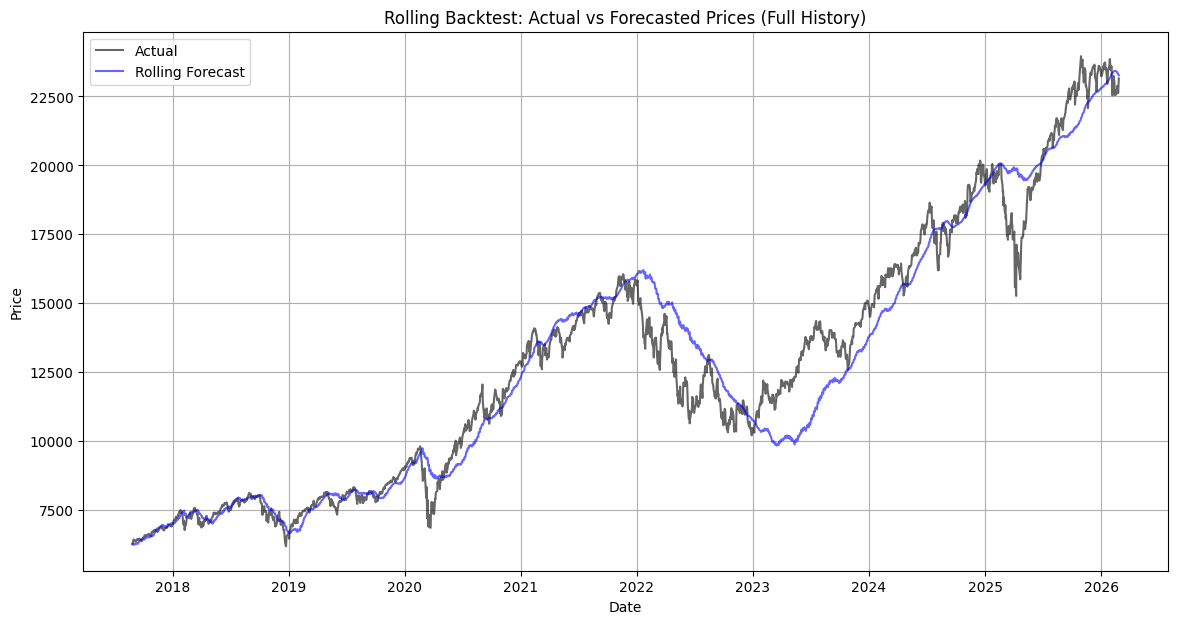

In [29]:
import matplotlib.pyplot as plt

# Plot Actual vs Rolling Forecast from Cross-Validation (Full History)
plt.figure(figsize=(14, 7))
plt.plot(df_cv['ds'], df_cv['y'], label='Actual', color='black', alpha=0.6)
plt.plot(df_cv['ds'], df_cv['yhat'], label='Rolling Forecast', color='blue', alpha=0.6)

plt.title('Rolling Backtest: Actual vs Forecasted Prices (Full History)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

Found 17 forecast records for February 2026.


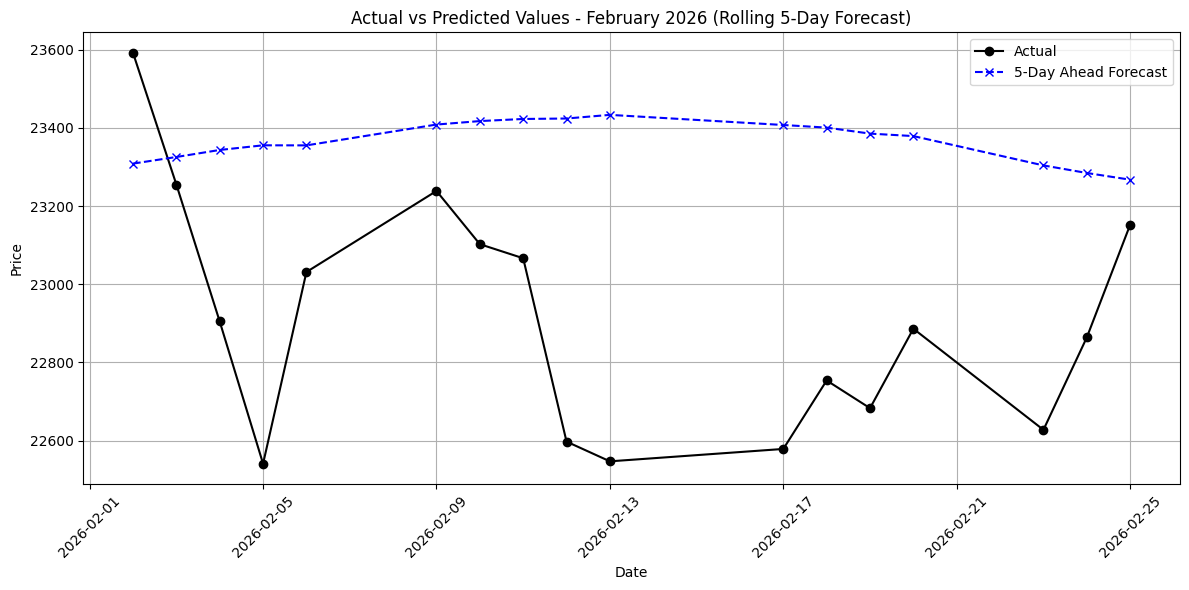

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter for February 2026 in the cross-validation results
start_date = '2026-02-01'
end_date = '2026-03-01'

mask = (df_cv['ds'] >= start_date) & (df_cv['ds'] < end_date)
df_feb_2026 = df_cv.loc[mask].copy()

print(f"Found {len(df_feb_2026)} forecast records for February 2026.")

# Plot
if not df_feb_2026.empty:
    plt.figure(figsize=(12, 6))
    # Plot Actual
    plt.plot(df_feb_2026['ds'], df_feb_2026['y'], label='Actual', marker='o', color='black')
    # Plot Forecast (yhat)
    plt.plot(df_feb_2026['ds'], df_feb_2026['yhat'], label='5-Day Ahead Forecast', marker='x', linestyle='--', color='blue')

    # Optional: Plot uncertainty intervals if desired, though might be cluttered for just 5 days
    # plt.fill_between(df_feb_2026['ds'], df_feb_2026['yhat_lower'], df_feb_2026['yhat_upper'], color='blue', alpha=0.1)

    plt.title('Actual vs Predicted Values - February 2026 (Rolling 5-Day Forecast)')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for the specified period. Check the cross-validation range.")